<a href="https://colab.research.google.com/github/AntoninaStadnik/ITStep-AI/blob/superwised_learning/%D0%94%D0%97_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_22.09_%D1%82%D0%B5%D1%81%D1%82_%D1%82%D1%80%D0%B5%D0%BD%D1%83%D0%B2%D0%B0%D0%BB%D1%8C%D0%BD%D1%96%D0%B4%D0%B0%D0%BD%D0%BD%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from google.colab import files
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [59]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")
df = df.drop(columns="Posted On")

[Ігформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [27]:
df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


# Завдання 1
* Очистіть дані від викидів
* Отримайте ознаки та цільову змінну(X, y)
* Розділіть дані на тренувальні та тестові

In [5]:
df.dtypes

,0
BHK,float64
Rent,float64
Size,float64
Floor,object
Area Type,object
Area Locality,object
City,object
Furnishing Status,object
Tenant Preferred,object
Bathroom,float64


<Axes: >

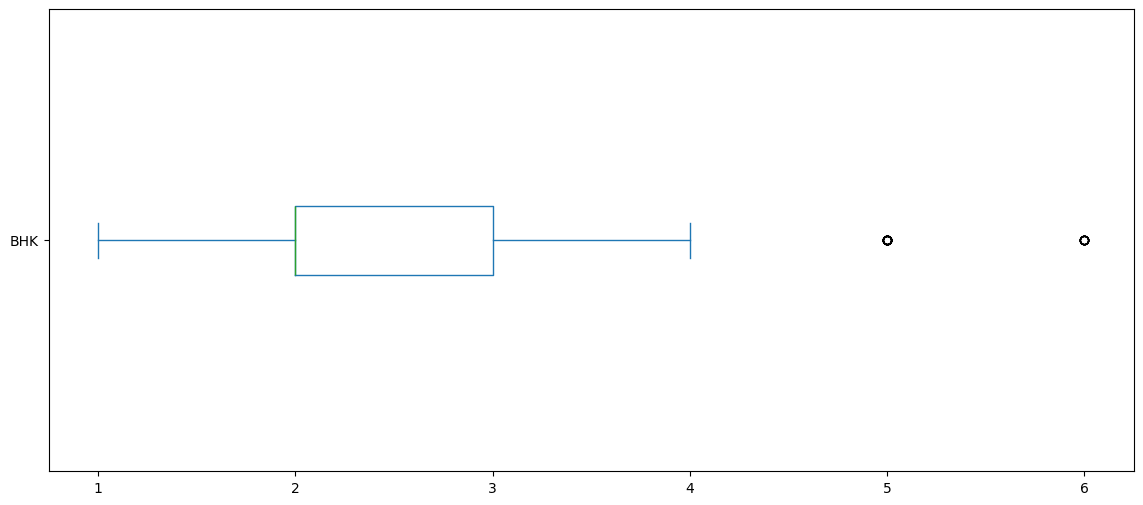

In [6]:
df['BHK'].plot(kind='box', vert=False, figsize=(14,6))

In [64]:
mask = df['Rent'] >= 2000
mask.sum()

np.int64(4367)

In [65]:
df = df[mask]

<Axes: >

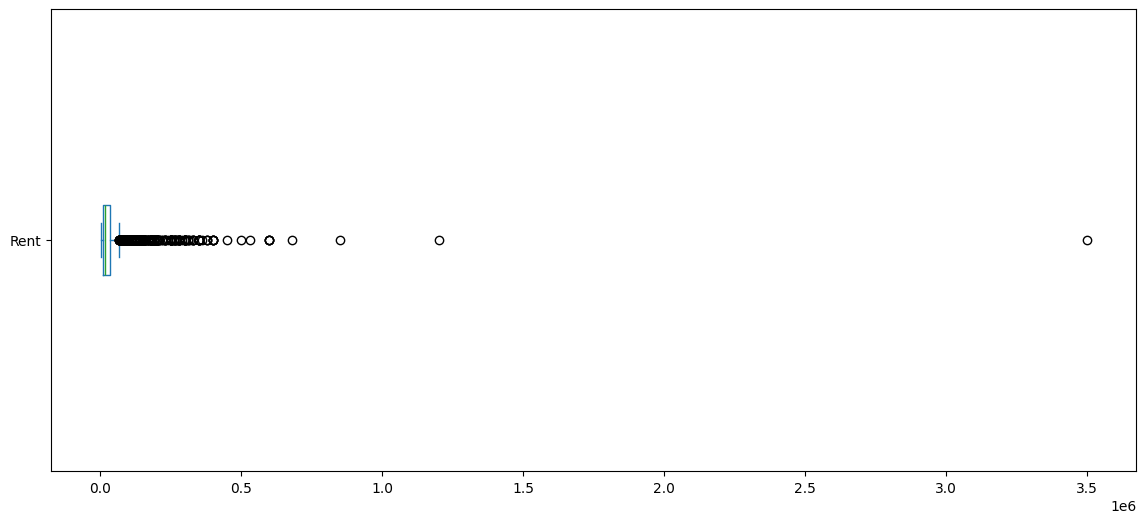

In [66]:
df['Rent'].plot(kind='box', vert=False, figsize=(14,6))

In [76]:
mask = df['Size'] >= 500
mask.sum()

np.int64(3317)

In [77]:
df = df[mask]

<Axes: >

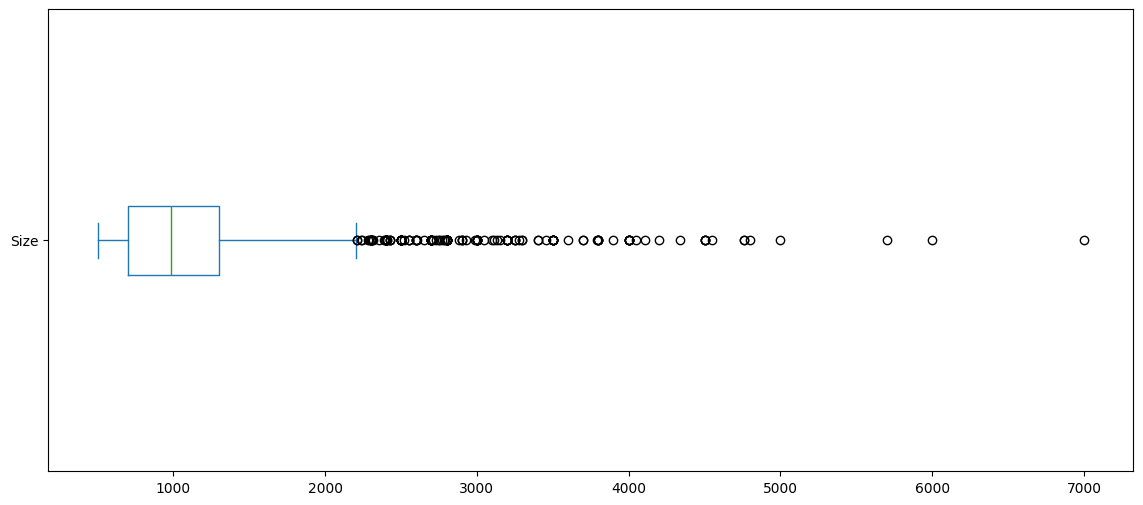

In [78]:
df['Size'].plot(kind='box', vert=False, figsize=(14,6))

In [88]:
mask = df['Bathroom'] >= 2
mask.sum()

np.int64(2407)

In [89]:
df = df[mask]

<Axes: >

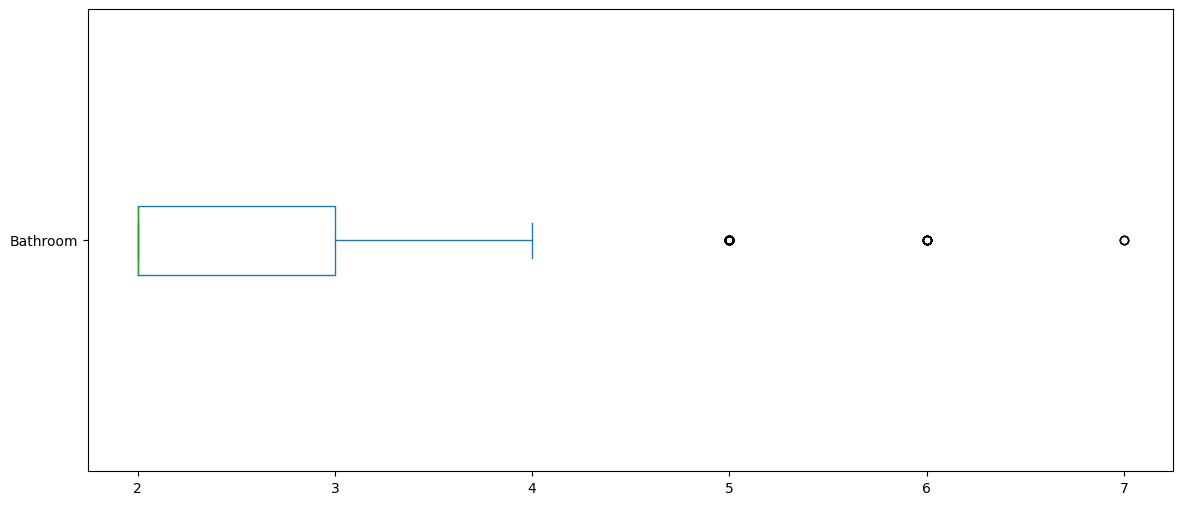

In [90]:
df['Bathroom'].plot(kind='box', vert=False, figsize=(14,6))

In [92]:

y = df['Rent']
x = df.drop(columns = 'Rent')

x

,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
5,2.0,600.0,Ground out of 1,Super Area,Thakurpukur,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
8,2.0,800.0,1 out of 2,Carpet Area,"Palm Avenue Kolkata, Ballygunge",Kolkata,Unfurnished,Bachelors,2.0,Contact Agent
10,3.0,1200.0,1 out of 4,Carpet Area,"Action Area 1, Rajarhat Newtown",Kolkata,Semi-Furnished,Bachelors/Family,2.0,Contact Agent
14,3.0,900.0,Ground out of 2,NaN,Paschim Barisha,Kolkata,Unfurnished,Bachelors,2.0,Contact Owner
...,...,...,...,...,...,...,...,...,...,...
4741,NaN,1000.0,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2.0,Contact Owner
4742,3.0,2000.0,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner
4743,3.0,1750.0,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Agent
4744,3.0,1500.0,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2.0,Contact Agent


In [95]:
X = df.drop("Rent", axis=1) #розподілення на х та у - для розподілення данних на навчання і верифікацію
y = df["Rent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(1925, 10)
(482, 10)


In [96]:
X_train.shape

(1925, 10)

# Завдання 2
Створіть Pipeline для обробки даних числових та категоріальних даних

In [98]:
numeric_features = ['BHK', 'Size', 'Bathroom']

categorical_features = [
    'Floor',
    'Area Type',
    'Area Locality',
    'City',
    'Furnishing Status',
    'Tenant Preferred',
    'Point of Contact'
]


In [99]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [100]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [101]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])


In [102]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)


(1925, 1409)
(482, 1409)


# Завдання 3
Об'єднайте препроцесор з деревом рішень в один пайплайн

In [106]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])


In [107]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BHK', 'Size', 'Bathroom']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Floor', 'Area Type',
                                                   'Area Locality', 'City',
                                                   'Furnishing Status',
                                                   'Tenant Preferred',
                                                   'Point of Contact'])])),
                ('regressor', DecisionTreeRegressor(random_state=42))])

# Завдання 4
Виведіть основні метрики моделі

In [111]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 27925.42531120332
MSE: 26665254884.36307
RMSE: 163294.9934454914
R²: 0.04600480180735789


# Завдання 5
Змініть параметри моделі та попробуйте покращити результат та натренуйте його

In [112]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [113]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  27328.39
MSE:  26219422090.12
RMSE: 161924.12
R²:   0.0620


# Завдання 6
Спрогнозуйте ціну оренди на тестових даних та порівняйте зі справжніми

In [108]:
y_pred = model.predict(X_test)

print(y_pred[:10])


[  9000.  70000.  11000.  10000.  22500.  80000.  80000. 120000.  30000.
  40000.]
